In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

Importing plotly failed. Interactive plots will not work.


#### Load dataset

In [3]:
df = pd.read_csv("../data/cleaned/cleaned_retail.csv")

#### Preprocessing

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#### Create Daily Sales Dataset

In [5]:
sales = df.groupby('InvoiceDate')['TotalPrice'].sum().reset_index()

In [6]:
sales.columns = ['ds', 'y']

In [7]:
sales.head()

,ds,y
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


#### Aggregate Daily Series

In [8]:
sales = sales.resample('D', on='ds').sum().reset_index()

In [9]:
sales['y'] = sales['y'].fillna(0)
sales.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-04,0.00
4,2010-12-05,31361.28


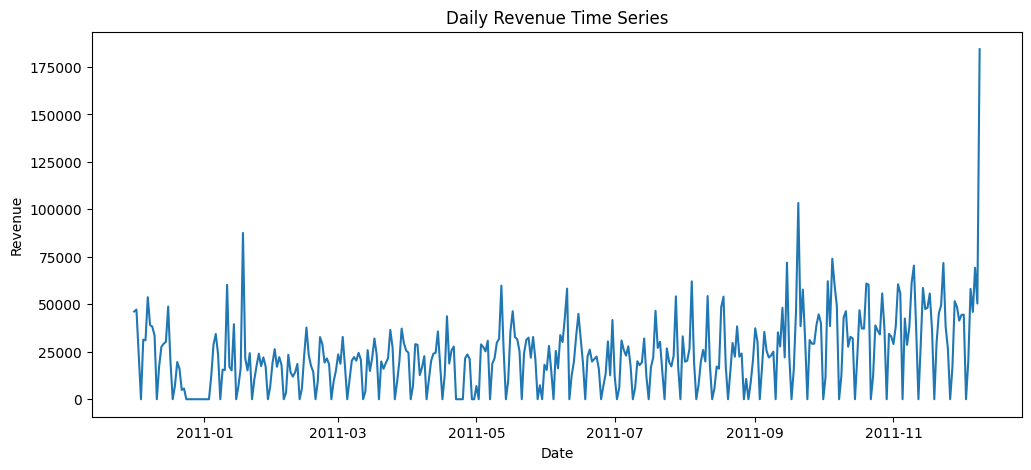

In [10]:
plt.figure(figsize=(12,5))

plt.plot(sales["ds"], sales["y"])

plt.title("Daily Revenue Time Series")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

#### Train Prophet Model

In [11]:
model = Prophet()

model.fit(sales)

20:48:44 - cmdstanpy - INFO - Chain [1] start processing
20:48:44 - cmdstanpy - INFO - Chain [1] done processing


#### Generate Future Dates and Forcast future sales

In [12]:
future = model.make_future_dataframe(periods=30)

In [13]:
forecast = model.predict(future)

#### Forcast Preview

In [14]:
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(10)

,ds,yhat,yhat_lower,yhat_upper
394,2011-12-30,51428.680200,31793.281023,68188.912896
395,2011-12-31,24455.091505,7167.657481,41905.803916
396,2012-01-01,39378.901903,20843.804213,54962.777806
397,2012-01-02,50389.959497,33509.927127,68202.379311
398,2012-01-03,56796.592334,38453.542847,73388.600887
399,2012-01-04,54341.494892,36984.218480,72072.173312
400,2012-01-05,61643.027055,44879.611341,78575.092019
401,2012-01-06,52674.278032,35806.334084,69191.322360
402,2012-01-07,25700.689337,6819.739985,42816.522022
403,2012-01-08,40624.499735,23528.350803,58685.126302


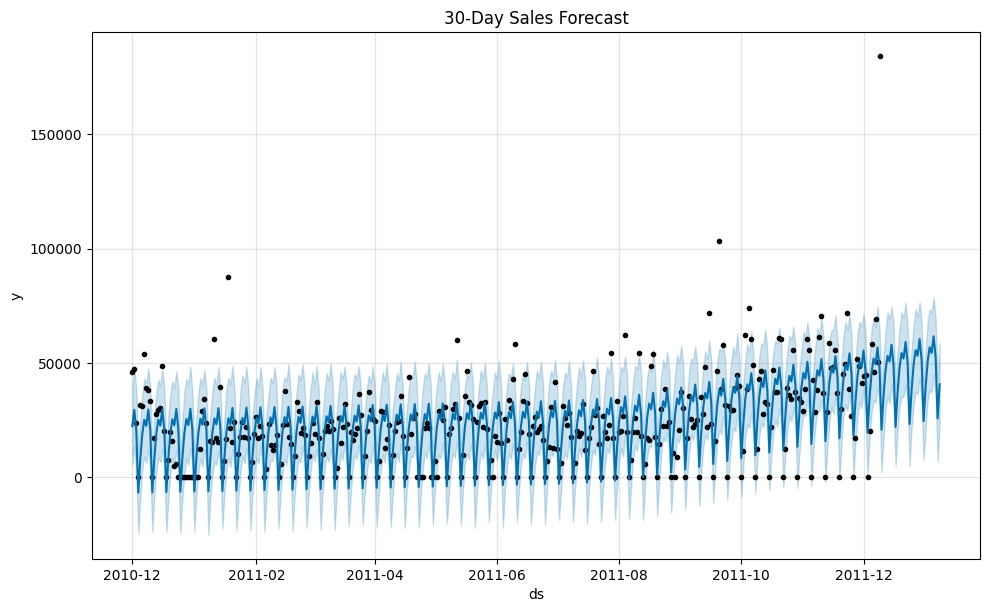

In [15]:
fig = model.plot(forecast)
plt.title("30-Day Sales Forecast")
plt.show()

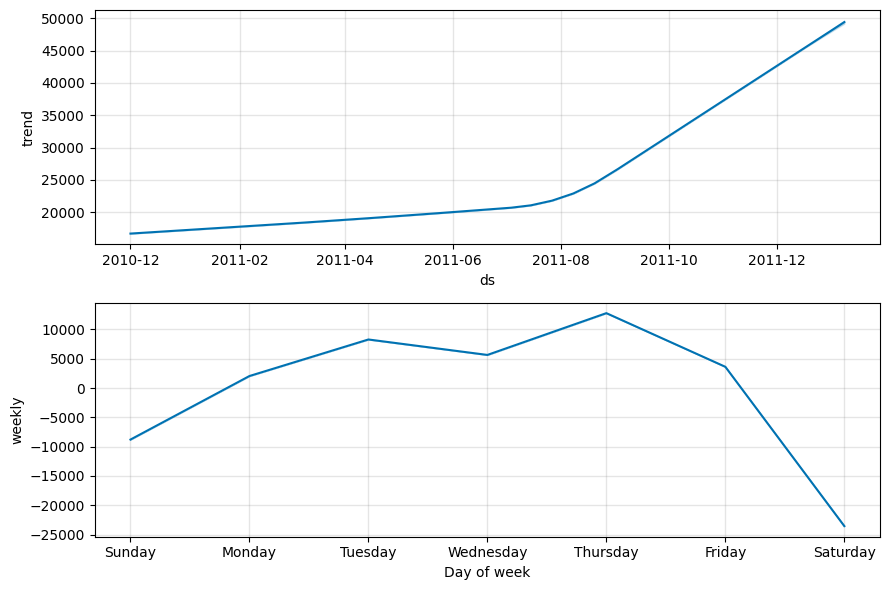

In [16]:
model.plot_components(forecast)
plt.show()

#### Save Forecast CSV

In [17]:
forecast.to_csv("../exports/forecast_results.csv", index=False)

#### Save Profet Model

In [18]:
import joblib

joblib.dump(model, "../models/prophet_model.pkl")

['../models/prophet_model.pkl']

#### MLflow Experiment Tracking

In [19]:
import mlflow
mlflow.start_run()

mlflow.log_param("model", "Prophet")
mlflow.log_param("forecast_days", 30)

mlflow.end_run()